# Validation Example: Couette Flow

This notebook demonstrates how to set up and run the **steady-state Couette flow** as the using the **FEM** module.

## Problem description

| Parameter | Value |
|-----------|-------|
| Domain | $[0, 6] \times [0, 2]$ |
| Density $\rho$ | 1 |
| Viscosity $\mu$ | 1 |
| Top-wall velocity $V_w$ | 1 |
| Bottom wall | no-slip |
| Left / right | traction-free |
| Element order | Q9 (order = 2) |
| Mesh | 4 × 4 elements |

### Analytical solution

$$v_x(x,y) = \frac{V_w \, y}{b}, \qquad v_y = 0, \qquad p = p_{\mathrm{ref}}$$

## 1 - Imports

In [8]:
import unittest
import numpy as np

from fem import NavierStokesSolver, BoundaryCondition, BCType, BCVar

## 2 - Build the solver (run once)

We set up the domain, physics, and boundary conditions here and then execute the solver.

In [9]:
# ── Domain ────────────────────────────────────────────────────────────────────
a, b   = 6, 2          # width, height
nx = ny = 4            # elements per direction
order  = 2             # Q9 elements

# ── Physics ───────────────────────────────────────────────────────────────────
rho, mu = 1.0, 1.0
Vw      = 1.0          # top-wall speed

# ── Boundary conditions ───────────────────────────────────────────────────────
top = BoundaryCondition(
    name="moving-top-wall",
    boundary_key="top",
    type=BCType.DIRICHLET,
    variable=BCVar.VELOCITY,
    value=lambda x, y, t: (Vw, 0),
    apply_strong=True,
    metadata={"Vx": Vw, "Vy": 0},
)
bottom = BoundaryCondition(
    name="no-slip",
    boundary_key="bottom",
    type=BCType.DIRICHLET,
    variable=BCVar.VELOCITY,
    value=(0.0, 0.0),
    apply_strong=True,
    metadata={"note": "no-slip"},
)
outlet = BoundaryCondition(
    name="outlet-stressfree",
    boundary_key="right",
    type=BCType.NEUMANN,
    traction=lambda x, y, t: (0.0, 0.0),
    apply_strong=False,
    metadata={"description": "do-nothing / traction-free outlet"},
)
inlet = BoundaryCondition(
    name="inlet-stressfree",
    boundary_key="left",
    type=BCType.NEUMANN,
    traction=lambda x, y, t: (0.0, 0.0),
    apply_strong=False,
    metadata={"description": "do-nothing / traction-free inlet"},
)

# ── Solve ─────────────────────────────────────────────────────────────────────
sol = NavierStokesSolver.uniform_rectangular_domain_rect(
    nx, ny, a, b, order=order
)
sol.setup_physics(rho, mu)
sol.setup_boundary_conditions([bottom, outlet, top, inlet])
sol.solve_steadystate(u0=10, p0=100)

sol_vx, sol_vy, sol_p = sol.get_solution()
print("Solver finished.  Solution arrays:",
      sol_vx.shape, sol_vy.shape, sol_p.shape)

Iteration 0  : ||R||=2.615e+01, ||Δ||=4.899e+02, fixed_dofs=37, free_dofs = 150
Iteration 1  : ||R||=2.615e+01, ||Δ||=2.033e-14, fixed_dofs=37, free_dofs = 150

Solver finished.  Solution arrays: (81,) (81,) (25,)


## 3 - Analytical solution helpers

In [10]:
def vx_analytical(x, y):
    """Linear Couette profile."""
    return Vw * y / b

def vy_analytical(x, y):
    """Zero vertical velocity."""
    return np.zeros_like(np.asarray(y, dtype=float))

def p_analytical(x, y):
    """Uniform reference pressure."""
    ref = sol.p_ref_node.value
    if isinstance(x, (float, int)):
        return np.ones_like(np.asarray(y, dtype=float)) * ref
    elif isinstance(y, (float, int)):
        return np.ones_like(np.asarray(x, dtype=float)) * ref
    return ref

## 4 - Visualisation

Plotting the FEM result against the analytical solution gives a visual confirmation that matches the quantitative tests above.

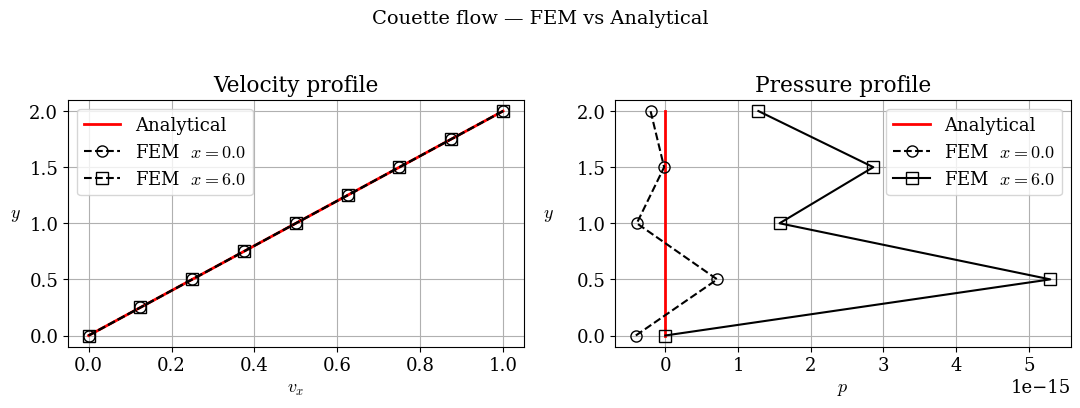

In [11]:
import matplotlib.pyplot as plt
from itertools import product as iproduct

plt.rcParams.update({'font.size': 13, 'font.family': 'serif',
                     'mathtext.fontset': 'cm'})

markers    = ['o', 's', '^', 'd']
linestyles = ['--', '-', '-.']
styles     = list(iproduct(linestyles, markers))

uni_x_clusters = sol.group_by_x()
filtered = {k: v for k, v in uni_x_clusters.items() if k in [0.0, a]}

# ── velocity profiles ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ref_con = filtered[a]
ax.plot(vx_analytical(a, sol.p2_nodes[ref_con, 1]),
        sol.p2_nodes[ref_con, 1], 'r', lw=2, label='Analytical')
for i, (xs, con) in enumerate(filtered.items()):
    ls, m = styles[i]
    ax.plot(sol_vx[con], sol.p2_nodes[con, 1],
            'k', marker=m, linestyle=ls, ms=8, markerfacecolor='none',
            label=f'FEM  $x={xs:.1f}$')
ax.set_xlabel('$v_x$')
ax.set_ylabel('$y$', rotation=0, labelpad=10)
ax.set_title('Velocity profile')
ax.legend()
ax.grid()

# ── pressure profile ──────────────────────────────────────────────────────────
ax = axes[1]
p_con = [sol.vel_2_pres_mapping[n] for n in filtered[a]
         if n in sol.vel_2_pres_mapping]
ax.plot(p_analytical(a, sol.p1_nodes[p_con, 1]),
        sol.p1_nodes[p_con, 1], 'r', lw=2, label='Analytical')
for i, (xs, con) in enumerate(filtered.items()):
    pc = [sol.vel_2_pres_mapping[n] for n in con if n in sol.vel_2_pres_mapping]
    ls, m = linestyles[i], markers[i]
    ax.plot(sol_p[pc], sol.p1_nodes[pc, 1],
            'k', marker=m, linestyle=ls, ms=8, markerfacecolor='none',
            label=f'FEM  $x={xs:.1f}$')
ax.set_xlabel('$p$')
ax.set_ylabel('$y$', rotation=0, labelpad=20)
ax.set_title('Pressure profile')
ax.legend()
ax.grid()

fig.suptitle('Couette flow — FEM vs Analytical', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()